In [2]:
# Import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from rasterio.plot import show as display_raster

# Import from opencropphenotyping
from opencropphenotyping.io import read_band, write_png
from opencropphenotyping.traits import compute_crop_cover, create_vegetation_mask

In [3]:
# Find paths

project_root = Path.cwd().parent
output_dir_processed = project_root / "data" / "processed"
output_dir_images = project_root / "docs" / "images"
output_dir_figures = project_root / "docs" / "figures"
output_dir_results = project_root / "results"

In [4]:
# Create varuables

vegetation_threshold = 0.3

In [5]:
# Import NDVI image

ndvi_path = output_dir_processed / "ndvi.tif"
ndvi_raster = read_band(ndvi_path)
print(f"NDVI raster shape: {ndvi_raster[0].shape}, dtype: {ndvi_raster[0].dtype}")

NDVI raster shape: (512, 512), dtype: float32


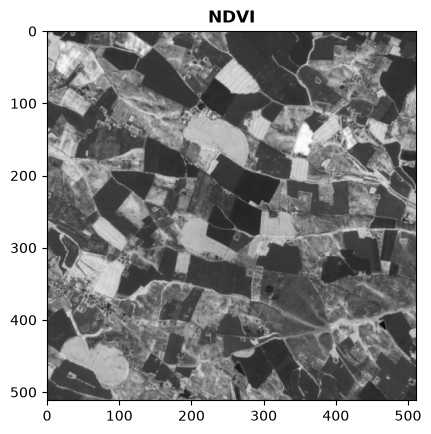

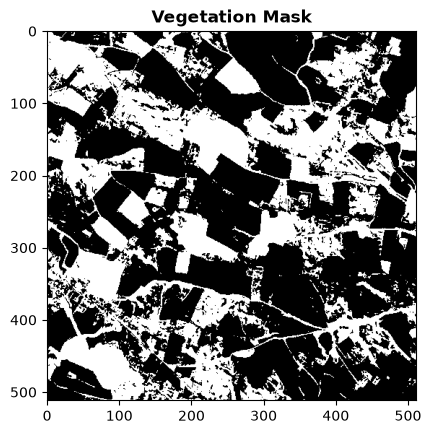

In [6]:
# Create and export the vegetation mask by thresholding the NDVI image

vegetation_mask = create_vegetation_mask(ndvi_raster[0], threshold=vegetation_threshold)
display_raster(ndvi_raster[0], cmap="gray", title="NDVI")
display_raster(vegetation_mask, cmap="gray", title="Vegetation Mask")
write_png(vegetation_mask, output_dir_images / "vegetation_mask.png")

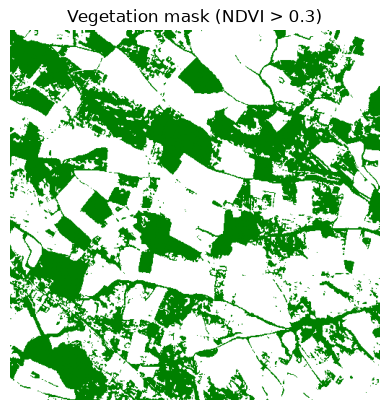

In [10]:
# Display the vegetation mask with a custom colormap

mask_display = np.where(
    np.isnan(vegetation_mask),
    -1,
    vegetation_mask
)

cmap = ListedColormap([
    "gray",    # NoData -1
    "white",   # Non-vegetation 0
    "green"    # Vegetation 1
])

fig, ax = plt.subplots()

ax.imshow(mask_display, cmap=cmap, vmin=-1, vmax=1)

ax.set_title(f"Vegetation mask (NDVI > {vegetation_threshold})")
ax.axis("off")

fig.savefig(
    output_dir_images / "vegetation_mask_custom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# Compute crop cover from the vegetation mask

crop_cover = compute_crop_cover(vegetation_mask)
print(f"Crop cover: {crop_cover:.2f}%")

Crop cover: 39.24%


In [9]:
# Quantification if the mask

unique, counts = np.unique(
    vegetation_mask[~np.isnan(vegetation_mask)],
    return_counts=True
)

dict(zip(unique, counts))

{np.float64(0.0): np.int64(159291), np.float64(1.0): np.int64(102853)}